## Stratification

**What problem does this notebook address?**

With plain KFold cross-validation (even when shuffling), the **class distribution can differ between training and test folds**. That means:

- You are not training and testing with class proportions similar to your full dataset or to production.
- Your performance estimate is less realistic, and metrics that depend on class proportion can be misleading.

**What we demonstrate:** We show how **stratified** cross-validation preserves the original class frequencies in every fold. That gives a more realistic and interpretable measure of the model’s ability to generalize, especially when metrics depend on the proportion of the positive class.

*Stratification* refers to the arrangement or classification of something into different groups or "strata". Stratifying is more effective than just shuffling when it comes to making sure that the distributions of classes in all the folds are representative of the entire dataset.

Let's demonstrate the problem with an example. Let’s load the iris dataset.

In [1]:
from sklearn.datasets import load_iris

data, target = load_iris(as_frame=True, return_X_y=True)

At this point, we create a basic machine-learning model: a logistic regression. We expect this model to work quite well on the iris dataset since this is a toy dataset.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

Once the model is created, we can evaluate it using cross-validation. We start by using the `KFold` strategy with shuffling:

- We define a dataset with nine samples
- and split the dataset into three folds (i.e. `n_splits=3`)
- and shuffle the data; since it is actually ordered (50 class A, 50 class B, 50 class C); which would be a problem


In [3]:
from sklearn.model_selection import KFold, cross_validate

n_splits = 3
cv = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=0
)

results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.953 ± 0.009


We get results that are closer to what we would expect with an accuracy above 90%. Now that we solved our first issue, it would be interesting to check if the class frequency in the training and testing set is equal to our original set’s class frequency. It would ensure that we are training and testing our model with a class distribution that we would encounter in production.

In [4]:
import pandas as pd

train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

The train set:


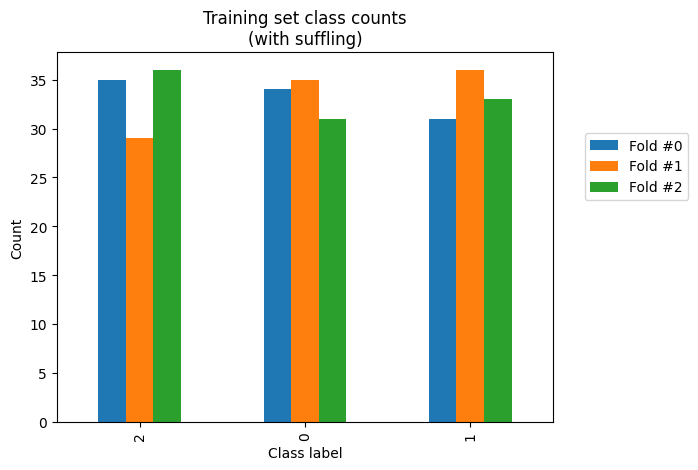

In [5]:
import matplotlib.pyplot as plt

train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set class counts\n(with suffling)")

And the test set:

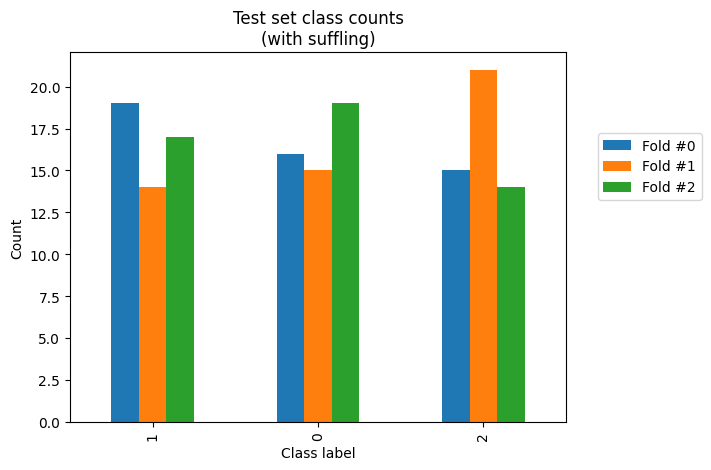

In [6]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set class counts\n(with suffling)")

We see that neither the training and testing sets have the same class frequencies as our original dataset because the count for each class is varying a little.

However, one might want to split our data by **preserving the original class frequencies**: we want to **stratify** our data by class. In scikit-learn, some cross-validation strategies implement the stratification; they contain Stratified in their names.


In [7]:
from sklearn.model_selection import StratifiedKFold

n_splits = 3
cv = StratifiedKFold(n_splits=n_splits)

results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.967 ± 0.009


Now let's look at the frequencies:


In [8]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

Plot them for the training set:

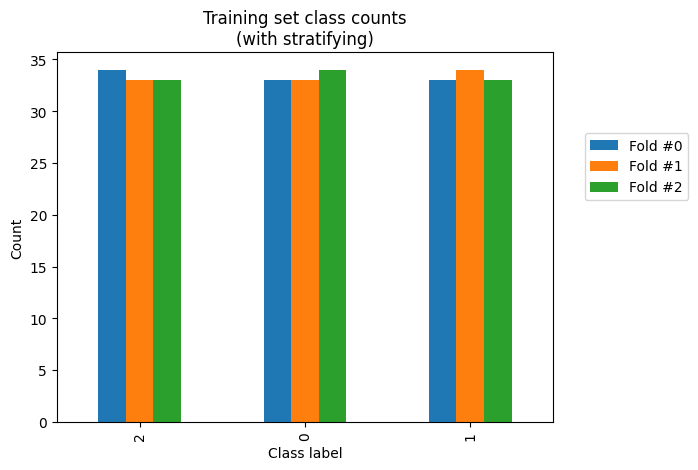

In [9]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set class counts\n(with stratifying)")

And the test set:


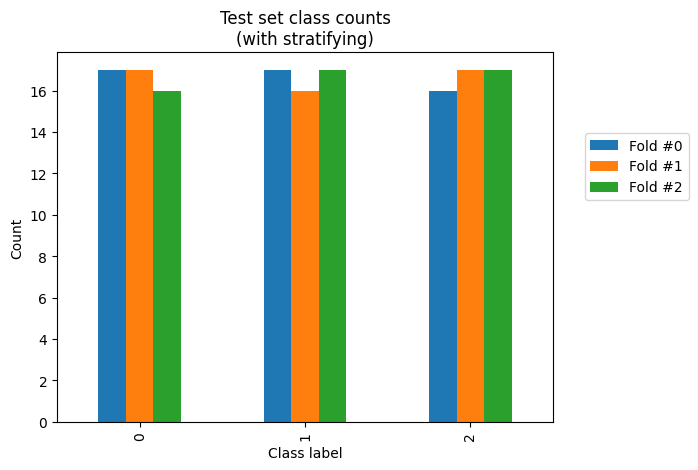

In [10]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set class counts\n(with stratifying)")

In this case, we observe that the class counts are very close both in the train set and the test set. The difference is due to the small number of samples in the iris dataset.

In other words, stratifying is more effective than just shuffling when it comes to making sure that the distributions of classes in all the folds are representative of the entire dataset. As training and testing folds have similar class distributions, **stratifying leads to a more realistic measure of the model’s ability to generalize**. This is specially important when the performance metrics depend on the proportion of the positive class, as we will see in a future notebook.

The interested reader can learn about other stratified cross-validation techniques in the [scikit-learn user guide](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-with-stratification-based-on-class-labels).